In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv(r'C:\Users\USER PC\Downloads\Airline_Delay_Cause.csv\Airline_Delay_Cause.csv')

In [6]:
data.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,7,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",33.0,2.0,0.92,1.00,...,0.0,0.00,0.0,0.0,129.0,98.0,23.0,8.0,0.0,0.0
1,2022,7,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",78.0,25.0,11.80,0.72,...,0.0,7.48,0.0,0.0,1664.0,887.0,52.0,224.0,0.0,501.0
2,2022,7,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",124.0,19.0,5.84,1.00,...,0.0,5.40,5.0,4.0,1523.0,388.0,35.0,511.0,0.0,589.0
3,2022,7,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",67.0,10.0,1.32,1.00,...,1.0,4.28,0.0,1.0,657.0,103.0,82.0,93.0,25.0,354.0
4,2022,7,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",174.0,30.0,18.10,5.75,...,0.0,2.55,1.0,0.0,2462.0,1686.0,310.0,139.0,0.0,327.0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101315 entries, 0 to 101314
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 101315 non-null  int64  
 1   month                101315 non-null  int64  
 2   carrier              101315 non-null  object 
 3   carrier_name         101315 non-null  object 
 4   airport              101315 non-null  object 
 5   airport_name         101315 non-null  object 
 6   arr_flights          101157 non-null  float64
 7   arr_del15            100960 non-null  float64
 8   carrier_ct           101157 non-null  float64
 9   weather_ct           101157 non-null  float64
 10  nas_ct               101157 non-null  float64
 11  security_ct          101157 non-null  float64
 12  late_aircraft_ct     101157 non-null  float64
 13  arr_cancelled        101157 non-null  float64
 14  arr_diverted         101157 non-null  float64
 15  arr_delay        

In [16]:
#Checking for missing values
data.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            158
arr_del15              355
carrier_ct             158
weather_ct             158
nas_ct                 158
security_ct            158
late_aircraft_ct       158
arr_cancelled          158
arr_diverted           158
arr_delay              158
carrier_delay          158
weather_delay          158
nas_delay              158
security_delay         158
late_aircraft_delay    158
dtype: int64

In [18]:
#Removing missing values
data = data.dropna()

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100960 entries, 0 to 101314
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 100960 non-null  int64  
 1   month                100960 non-null  int64  
 2   carrier              100960 non-null  object 
 3   carrier_name         100960 non-null  object 
 4   airport              100960 non-null  object 
 5   airport_name         100960 non-null  object 
 6   arr_flights          100960 non-null  float64
 7   arr_del15            100960 non-null  float64
 8   carrier_ct           100960 non-null  float64
 9   weather_ct           100960 non-null  float64
 10  nas_ct               100960 non-null  float64
 11  security_ct          100960 non-null  float64
 12  late_aircraft_ct     100960 non-null  float64
 13  arr_cancelled        100960 non-null  float64
 14  arr_diverted         100960 non-null  float64
 15  arr_delay            1

In [30]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [36]:
#Checking for duplicate columns
data.columns.duplicated().any()

False

In [52]:
#Ranking airlines by Delay Rate and Severity
data.loc[:,'delay_rate'] = data['arr_del15'] / data['arr_flights'] * 100
delay_rank = (
    data.groupby('carrier_name', as_index=False)['delay_rate']
    .mean()
    .sort_values('delay_rate',ascending=False)
)

In [54]:
delay_rank

,carrier_name,delay_rate
11,JetBlue Airways,22.894441
19,Virgin America,22.872254
8,Frontier Airlines Inc.,20.819233
6,ExpressJet Airlines Inc.,19.845831
9,Hawaiian Airlines Inc.,19.763630
1,Allegiant Air,19.654736
2,American Airlines Inc.,19.347540
16,Southwest Airlines Co.,18.514839
18,United Air Lines Inc.,18.326034
12,Mesa Airlines Inc.,18.240549


In [56]:
#Delay Cost per Airline(in USD and % of total)
cost_per_min = 74

In [68]:
data.loc[:,'delay_cost_usd'] = data['arr_delay'] * cost_per_min

In [70]:
delay_cost=(
    data.groupby('carrier_name',as_index=False)
    .agg(total_delay_cost_usd=('delay_cost_usd','sum'),
         avg_delay_cost_usd=('delay_cost_usd','mean'))
    .sort_values('total_delay_cost_usd',ascending=False)
)

In [72]:
delay_cost

,carrier_name,total_delay_cost_usd,avg_delay_cost_usd
16,Southwest Airlines Co.,4.549104e+09,738371.051128
2,American Airlines Inc.,4.087679e+09,608557.260384
15,SkyWest Airlines Inc.,3.791474e+09,255026.179592
3,Delta Air Lines Inc.,3.093439e+09,343562.735673
18,United Air Lines Inc.,2.719178e+09,418528.202247
11,JetBlue Airways,1.927307e+09,456924.438596
14,Republic Airline,1.019482e+09,222448.714816
17,Spirit Air Lines,9.449905e+08,305723.231317
13,PSA Airlines Inc.,8.302917e+08,188745.553990
12,Mesa Airlines Inc.,8.265892e+08,157206.005325


In [80]:
#Computing Each Airline's Share of Total Cost
total_cost_all = delay_cost['total_delay_cost_usd'].sum()
delay_cost['percent_of_total'] = (delay_cost['total_delay_cost_usd']/total_cost_all) * 100

In [78]:
delay_cost['percent_of_total']

16    15.920863
2     14.305977
15    13.269325
3     10.826355
18     9.516523
11     6.745151
14     3.567964
17     3.307259
13     2.905838
12     2.892880
5      2.869693
8      2.798156
4      2.496189
0      2.430853
6      2.294026
1      2.081980
7      0.644315
9      0.474190
19     0.354683
10     0.297780
Name: percent_of_total, dtype: float64

In [92]:
delay_cost['total_delay_cost_usd'] = delay_cost['total_delay_cost_usd'].round(2)
delay_cost['avg_delay_cost_usd'] = delay_cost['avg_delay_cost_usd'].round(2)
delay_cost['percen_of_total'] = delay_cost['percent_of_total'].round(2)

In [94]:
delay_cost.head(10)

,carrier_name,total_delay_cost_usd,avg_delay_cost_usd,percent_of_total,percen_of_total
16,Southwest Airlines Co.,4.549104e+09,738371.05,15.920863,15.92
2,American Airlines Inc.,4.087679e+09,608557.26,14.305977,14.31
15,SkyWest Airlines Inc.,3.791474e+09,255026.18,13.269325,13.27
3,Delta Air Lines Inc.,3.093439e+09,343562.74,10.826355,10.83
18,United Air Lines Inc.,2.719178e+09,418528.20,9.516523,9.52
11,JetBlue Airways,1.927307e+09,456924.44,6.745151,6.75
14,Republic Airline,1.019482e+09,222448.71,3.567964,3.57
17,Spirit Air Lines,9.449905e+08,305723.23,3.307259,3.31
13,PSA Airlines Inc.,8.302917e+08,188745.55,2.905838,2.91
12,Mesa Airlines Inc.,8.265892e+08,157206.01,2.892880,2.89


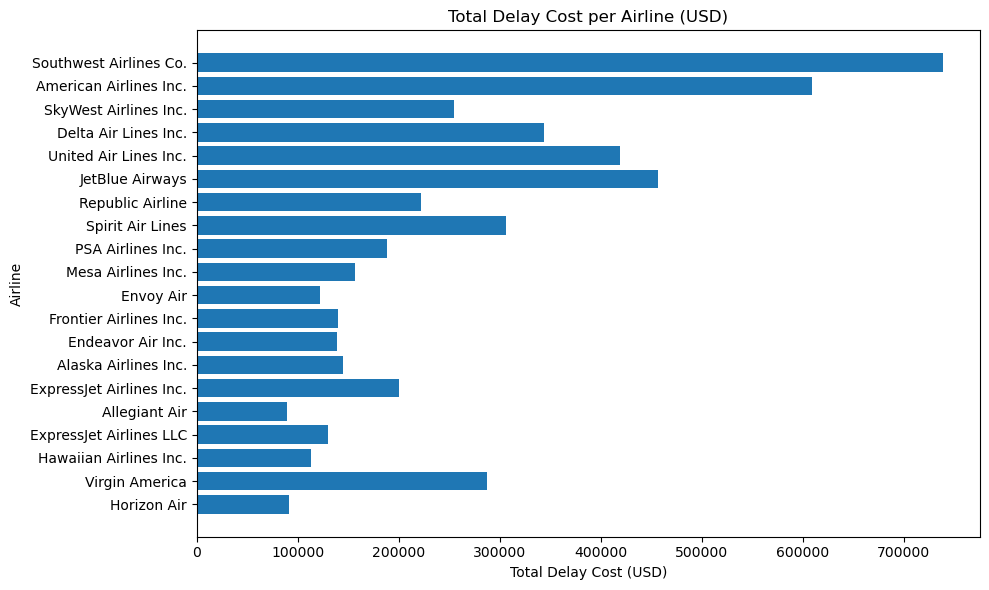

In [104]:
#Which airline is losing the most money to delays.
plt.figure(figsize=(10,6))
plt.barh(delay_cost['carrier_name'], delay_cost['avg_delay_cost_usd'])
plt.gca().invert_yaxis()
plt.title('Total Delay Cost per Airline (USD)')
plt.xlabel('Total Delay Cost (USD)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

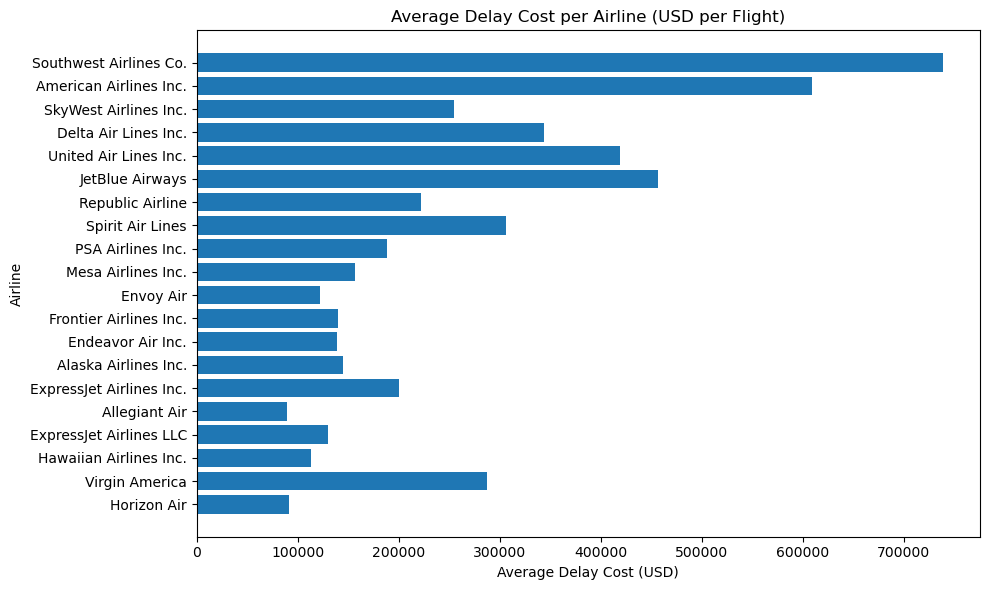

In [106]:
#Which airline has the most expensive delays per operation
plt.figure(figsize=(10,6))
plt.barh(delay_cost['carrier_name'], delay_cost['avg_delay_cost_usd'])
plt.gca().invert_yaxis()
plt.title('Average Delay Cost per Airline (USD per Flight)')
plt.xlabel('Average Delay Cost (USD)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

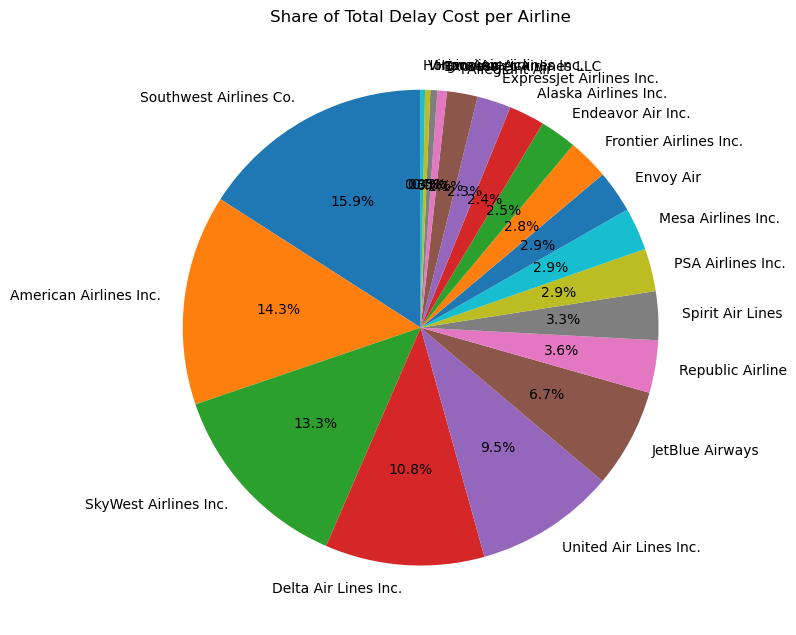

In [114]:
#Contribution of each airline to industry-wide loss
plt.figure(figsize=(8,8))
plt.pie(
    delay_cost['percent_of_total'],
    labels=delay_cost['carrier_name'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Share of Total Delay Cost per Airline')
plt.tight_layout()
plt.show()

In [120]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'felay_rate', 'delay_rate',
       'delay_cost_usd', 'carrier_share', 'late_aircraft_share',
       'weather_share', 'nas_share', 'security_share'],
      dtype='object')

In [122]:
data = data.copy()

In [124]:
data.loc[:,'carrier_share'] = (data['carrier_delay']/data['arr_delay'])*100
data.loc[:,'late_aircraft_share'] = (data['late_aircraft_delay']/data['arr_delay'])*100
data.loc[:,'weather_share'] = (data['weather_delay']/data['arr_delay'])*100
data.loc[:,'nas_share'] = (data['nas_delay']/data['arr_delay'])*100
data.loc[:,'security_share'] = (data['security_delay']/data['arr_delay'])*100 

In [140]:
delay_cause_summary = (
    data.groupby('carrier_share',as_index=False)[
          ['carrier_share','late_aircraft_share','weather_share','nas_share','security_share']
    ].mean()
)

In [156]:
delay_cause_summary['controllable_pct'] = (
    delay_cause_summary['carrier_share'] + delay_cause_summary['late_aircraft_share']
)
delay_cause_summary['uncontrollable_pct'] = (
    delay_cause_summary['weather_share'] + delay_cause_summary['nas_share'] + delay_cause_summary['security_share']
)

In [142]:
delay_cause_summary['controllable_pct'] = (
    delay_cause_summary['carrier_share'] + delay_cause_summary['late_aircraft_share']
)
delay_cause_summary['uncontrollable_pct'] = (
    delay_cause_summary['weather_share'] + delay_cause_summary['nas_share'] + delay_cause_summary['security_share']
)

In [148]:
delay_cause_summary.index.names
delay_cause_summary.columns.tolist()

['carrier_share',
 'late_aircraft_share',
 'weather_share',
 'nas_share',
 'security_share',
 'controllable_pct',
 'uncontrollable_pct']

In [150]:
delay_cause_summary.columns.tolist()

['carrier_share',
 'late_aircraft_share',
 'weather_share',
 'nas_share',
 'security_share',
 'controllable_pct',
 'uncontrollable_pct']

In [152]:
delay_cause_summary = (
    data.groupby('carrier_name',as_index=False)[
          ['carrier_share','late_aircraft_share','weather_share','nas_share','security_share']
    ].mean()
)

In [160]:
delay_cause_summary = delay_cause_summary.sort_values('controllable_pct',ascending=False)
delay_cause_summary[['carrier_name','controllable_pct','uncontrollable_pct']].head(10)


#The airline is mostly delaying itself, from the analysis controllable pct are the major causees of delay. I recommend internal re-evaluation

,carrier_name,controllable_pct,uncontrollable_pct
9,Hawaiian Airlines Inc.,95.722472,4.277528
16,Southwest Airlines Co.,84.115604,15.884396
15,SkyWest Airlines Inc.,79.198485,20.801515
10,Horizon Air,77.560797,22.439203
2,American Airlines Inc.,76.940068,23.059932
11,JetBlue Airways,76.077427,23.922573
12,Mesa Airlines Inc.,74.992046,25.007954
18,United Air Lines Inc.,74.031928,25.968072
6,ExpressJet Airlines Inc.,73.752048,26.247952
8,Frontier Airlines Inc.,73.124819,26.873579


In [164]:
#Delay Rate vs Cancel Rate
data['delay_rate'] = (data['arr_del15']/data['arr_flights'])*100
data['cancel_rate'] = (data['arr_cancelled']/data['arr_flights'])*100

In [174]:
delay_cause_summary = (
    data.groupby('carrier_name',as_index=False)[['delay_rate','cancel_rate']].mean()
)

In [168]:
delay_cause_summary

,carrier_name,delay_rate,cancel_rate
0,Alaska Airlines Inc.,14.870265,1.972474
1,Allegiant Air,19.654736,4.124873
2,American Airlines Inc.,19.347540,2.545233
3,Delta Air Lines Inc.,12.835616,1.386284
4,Endeavor Air Inc.,12.449951,2.021130
5,Envoy Air,15.580235,3.335439
6,ExpressJet Airlines Inc.,19.845831,3.118698
7,ExpressJet Airlines LLC,18.237631,6.306792
8,Frontier Airlines Inc.,20.819233,2.771314
9,Hawaiian Airlines Inc.,19.763630,0.702219


In [178]:
delay_cause_summary.head()

,carrier_name,delay_rate,cancel_rate
0,Alaska Airlines Inc.,14.870265,1.972474
1,Allegiant Air,19.654736,4.124873
2,American Airlines Inc.,19.347540,2.545233
3,Delta Air Lines Inc.,12.835616,1.386284
4,Endeavor Air Inc.,12.449951,2.021130


In [188]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'felay_rate', 'delay_rate',
       'delay_cost_usd', 'carrier_share', 'late_aircraft_share',
       'weather_share', 'nas_share', 'security_share', 'cancel_rate'],
      dtype='object')

In [212]:
#Carrier delay, weather delay
delay_cost = data.groupby('carrier_name', as_index=False)[
    ['carrier_delay','late_aircraft_delay','weather_delay','nas_delay','security_delay']
].sum()

delay_cost

,carrier_name,carrier_delay,late_aircraft_delay,weather_delay,nas_delay,security_delay
0,Alaska Airlines Inc.,2833446.0,3037111.0,305217.0,3157291.0,53058.0
1,Allegiant Air,2705934.0,3417911.0,513875.0,1374208.0,27110.0
2,American Airlines Inc.,19875173.0,20836297.0,2826089.0,11572205.0,129143.0
3,Delta Air Lines Inc.,17195017.0,11497398.0,2916252.0,10134287.0,59765.0
4,Endeavor Air Inc.,3066009.0,3503258.0,749232.0,2315262.0,4639.0
5,Envoy Air,2698921.0,4244473.0,1151168.0,2971594.0,14436.0
6,ExpressJet Airlines Inc.,3166031.0,2906254.0,256167.0,2529348.0,0.0
7,ExpressJet Airlines LLC,761681.0,697855.0,101006.0,927317.0,0.0
8,Frontier Airlines Inc.,3126406.0,4926297.0,199118.0,2552335.0,0.0
9,Hawaiian Airlines Inc.,1160165.0,560471.0,69614.0,29154.0,11560.0


In [214]:
#Total delay minutes
delay_cost['total_delay_min']=(
    delay_cost['carrier_delay'] + delay_cost['late_aircraft_delay'] +
    delay_cost['weather_delay'] + delay_cost['nas_delay'] + delay_cost['security_delay']
)
delay_cost

,carrier_name,carrier_delay,late_aircraft_delay,weather_delay,nas_delay,security_delay,total_delay_min
0,Alaska Airlines Inc.,2833446.0,3037111.0,305217.0,3157291.0,53058.0,9386123.0
1,Allegiant Air,2705934.0,3417911.0,513875.0,1374208.0,27110.0,8039038.0
2,American Airlines Inc.,19875173.0,20836297.0,2826089.0,11572205.0,129143.0,55238907.0
3,Delta Air Lines Inc.,17195017.0,11497398.0,2916252.0,10134287.0,59765.0,41802719.0
4,Endeavor Air Inc.,3066009.0,3503258.0,749232.0,2315262.0,4639.0,9638400.0
5,Envoy Air,2698921.0,4244473.0,1151168.0,2971594.0,14436.0,11080592.0
6,ExpressJet Airlines Inc.,3166031.0,2906254.0,256167.0,2529348.0,0.0,8857800.0
7,ExpressJet Airlines LLC,761681.0,697855.0,101006.0,927317.0,0.0,2487859.0
8,Frontier Airlines Inc.,3126406.0,4926297.0,199118.0,2552335.0,0.0,10804156.0
9,Hawaiian Airlines Inc.,1160165.0,560471.0,69614.0,29154.0,11560.0,1830964.0


In [216]:
#Compute monetary cost of delay(cost_per_min = 74 usd)
delay_cost['total_delay_cost_usd'] = delay_cost['total_delay_min'] * cost_per_min
delay_cost['total_delay_cost_usd']

0     6.945731e+08
1     5.948888e+08
2     4.087679e+09
3     3.093401e+09
4     7.132416e+08
5     8.199638e+08
6     6.554772e+08
7     1.841016e+08
8     7.995075e+08
9     1.354913e+08
10    8.508542e+07
11    1.927307e+09
12    8.265892e+08
13    8.302917e+08
14    1.019482e+09
15    3.791474e+09
16    4.549104e+09
17    9.449905e+08
18    2.719178e+09
19    1.013444e+08
Name: total_delay_cost_usd, dtype: float64

In [208]:
for cause in ['carrier', 'late_aircraft','weather','nas','security']:
    delay_cost[f'{cause}_cost_usd'] = delay_cost[f'{cause}_delay'] * cost_per_min

In [210]:
delay_cost[f'{cause}_cost_usd']

0      3926292.0
1      2006140.0
2      9556582.0
3      4422610.0
4       343286.0
5      1068264.0
6            0.0
7            0.0
8            0.0
9       855440.0
10      270988.0
11     4667032.0
12     1059310.0
13     1522032.0
14     1079808.0
15     4851440.0
16    12983596.0
17     5818990.0
18      385688.0
19      354460.0
Name: security_cost_usd, dtype: float64

In [222]:
#Total delay cost in percentage
delay_cost['cost_share_%'] = (
    delay_cost['total_delay_cost_usd'] / delay_cost['total_delay_cost_usd'].sum()
    ) * 100
delay_cost['cost_share_%']

0      2.430858
1      2.081984
2     14.306004
3     10.826244
4      2.496193
5      2.869698
6      2.294030
7      0.644316
8      2.798106
9      0.474191
10     0.297781
11     6.745164
12     2.892886
13     2.905844
14     3.567971
15    13.269350
16    15.920893
17     3.307265
18     9.516541
19     0.354684
Name: cost_share_%, dtype: float64

In [236]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'felay_rate', 'delay_rate',
       'delay_cost_usd', 'carrier_share', 'late_aircraft_share',
       'weather_share', 'nas_share', 'security_share', 'cancel_rate'],
      dtype='object')

In [238]:
delay_cost.head()

,carrier_name,carrier_delay,late_aircraft_delay,weather_delay,nas_delay,security_delay,total_delay_min,total_delay_cost_usd,cost_share_%,controllable_delay_min,saved_minues
0,Alaska Airlines Inc.,2833446.0,3037111.0,305217.0,3157291.0,53058.0,9386123.0,6.945731e+08,2.430858,5870557.0,587055.7
1,Allegiant Air,2705934.0,3417911.0,513875.0,1374208.0,27110.0,8039038.0,5.948888e+08,2.081984,6123845.0,612384.5
2,American Airlines Inc.,19875173.0,20836297.0,2826089.0,11572205.0,129143.0,55238907.0,4.087679e+09,14.306004,40711470.0,4071147.0
3,Delta Air Lines Inc.,17195017.0,11497398.0,2916252.0,10134287.0,59765.0,41802719.0,3.093401e+09,10.826244,28692415.0,2869241.5
4,Endeavor Air Inc.,3066009.0,3503258.0,749232.0,2315262.0,4639.0,9638400.0,7.132416e+08,2.496193,6569267.0,656926.7


In [256]:
delay_cost['controllable_delay_min'] = (
    delay_cost['carrier_delay'] + delay_cost['late_aircraft_delay']
)

In [266]:
delay_cost.columns.tolist()

['carrier_name',
 'carrier_delay',
 'late_aircraft_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'controllable_delay_min',
 'saved_miutes']

In [270]:
#Renaming "saved_minutes" recorded as "save_miutes"
delay_cost.rename(columns={'saved_miutes': 'saved_minutes'}, inplace=True)

In [274]:
#ROI Scnerio Calculation
reduction_rate = 0.10 #10% improvement target

#Saved minutes and savings
delay_cost['saved_miutes'] = delay_cost['controllable_delay_min'] * reduction_rate
delay_cost['potential_savings_usd'] = delay_cost['saved_minutes'] * cost_per_min

#Display
delay_cost[['carrier_name','saved_minutes','potential_savings_usd']].head()

#Whwn you reduce the controllable delays by 10% the airline will be able to save the below number of minutes and and amount(in usd).

,carrier_name,saved_minutes,potential_savings_usd
0,Alaska Airlines Inc.,587055.7,43442121.8
1,Allegiant Air,612384.5,45316453.0
2,American Airlines Inc.,4071147.0,301264878.0
3,Delta Air Lines Inc.,2869241.5,212323871.0
4,Endeavor Air Inc.,656926.7,48612575.8


In [278]:
delay_cost.columns.tolist()

['carrier_name',
 'carrier_delay',
 'late_aircraft_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'controllable_delay_min',
 'saved_minutes',
 'saved_miutes',
 'potential_savings_usd']